In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

# Display setting
pd.set_option('display.max_columns',None)
sns.set_theme(style="darkgrid")

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# load the dataset
df = pd.read_csv("C:/Users/Dell/churn-prediction/data/telco_churn.csv")

# first look
print("shape:",df.shape)
print("\nfirst 5 row:")
df.head()

shape: (7043, 21)

first 5 row:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# column type and null value
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
# check totalcharge problem
print(df['TotalCharges'].unique()[:20])

# find hidden empty values
problem_rows = df[df['TotalCharges'].str.strip() =='']
print("\nNumber of problem rows:",len(problem_rows))
print(problem_rows[['customerID','tenure','TotalCharges']])


['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95' '587.45' '326.8' '5681.1' '5036.3' '2686.05'
 '7895.15' '1022.95' '7382.25' '528.35' '1862.9']

Number of problem rows: 11
      customerID  tenure TotalCharges
488   4472-LVYGI       0             
753   3115-CZMZD       0             
936   5709-LVOEQ       0             
1082  4367-NUYAO       0             
1340  1371-DWPAZ       0             
3331  7644-OMVMY       0             
3826  3213-VVOLG       0             
4380  2520-SGTTA       0             
5218  2923-ARZLG       0             
6670  4075-WKNIU       0             
6754  2775-SEFEE       0             


In [6]:
# Fix TotalCharges — convert to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill NaN with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verify fix
print("TotalCharges dtype now:", df['TotalCharges'].dtype)
print("Any nulls left?", df['TotalCharges'].isnull().sum())
print("\nMin value:", df['TotalCharges'].min())

TotalCharges dtype now: float64
Any nulls left? 0

Min value: 0.0


In [7]:
# check null in entire dataset 
print("null values in each column:")
print(df.isnull().sum())

print("\nTotal null values:",df.isnull().sum().sum())



null values in each column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Total null values: 0


In [8]:
# check churn distribution
print('Churn distribution:')
print(df['Churn'].value_counts())

print("\nChurn percentage:")
print(df['Churn'].value_counts(normalize=True) *100)

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [9]:
# statistical summary of numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


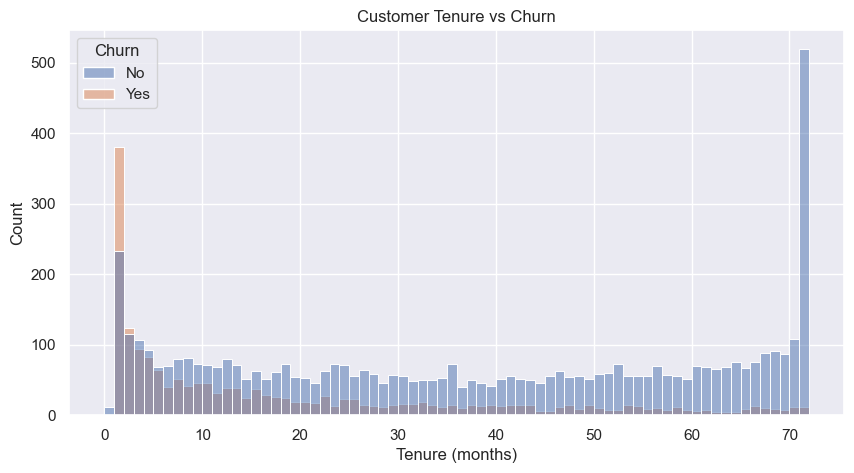

In [10]:
# plot churn vs tenure
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='tenure',hue='Churn', bins=72) 
plt.title('Customer Tenure vs Churn')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.show()

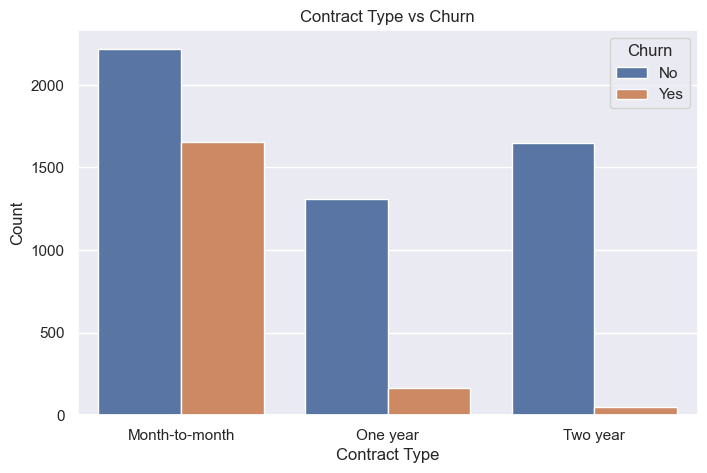

In [11]:
# plot churn vs contract type
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title('Contract Type vs Churn')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

In [12]:
# drop customerID 
df = df.drop(columns=['customerID'])

print("Columns remaining:", df.shape[1])
print(df.columns.tolist())

Columns remaining: 20
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [13]:
# Save cleaned dataframe
df.to_csv('../data/telco_churn_cleaned.csv', index=False)

print("Cleaned data saved!")
print("Shape:", df.shape)

Cleaned data saved!
Shape: (7043, 20)
